In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
from pathlib import Path
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore', category=RuntimeWarning)
print('Imports OK')

Imports OK


In [2]:
# ── Cell 2: Paths + subjects ──────────────────────────────────────────────────
_BASE = (
    '/Users/farjam/Library/CloudStorage'
    '/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP'
)
ECOC_ROOT  = Path(_BASE) / 'ECOC'
NR_ROOT    = Path(_BASE) / 'NR'
PLOTS_ROOT = Path(_BASE) / 'Plots'
(PLOTS_ROOT / 'Results').mkdir(parents=True, exist_ok=True)
RES_DIR    = PLOTS_ROOT / 'Results'   # all plots from this notebook go here

AGE_DATA = {
    '1001': 25.0, '1002': 43.0, '1004': 33.0, '1005': 50.0, '1007': 31.0,
    '1008': 25.0, '1010': 26.0, '1011': 37.0, '1014': 23.0, '1016': 36.0,
    '1017': 46.0, '1018': 25.0, '1020': 29.0, '1021': 28.0, '1023': 46.0,
    '1024': 24.0, '1026': 25.0, '1028': 62.0, '1034': 60.0, '1038': 45.0,
    '1039': 63.0, '1041': 49.0, '1042': 39.0, '1044': 62.0, '1046': 61.0,
    '1052': 53.0, '2002': 62.0, '2006': 25.0, '2009': 49.0, '2017': 31.0,
    '2020': 43.0, '2023': 49.0, '2026': 47.0, '2028': 29.0, '2029': 50.0,
    '2037': 45.0, '3001': 54.0, '3005': 39.0, '3006': 33.0, '3007': 41.0,
    '3008': 32.0, '3011': 31.0, '3014': 34.0, '3016': 44.0, '3027': 72.0,
    '3030': 54.0, '3034': 48.0, '3039': 34.0, '3041': 35.0,
}
SUBJECTS = list(AGE_DATA.keys())

PATHWAYS = {
    'Luminance': {
        'contrasts': np.array([0.035, 0.07,  0.14,  0.28],  float),
        'color':     '#555555',
    },
    'L-M': {
        'contrasts': np.array([0.008, 0.016, 0.032, 0.064], float),
        'color':     '#b23333',
    },
    'S-cone': {
        'contrasts': np.array([0.06,  0.12,  0.24,  0.48],  float),
        'color':     '#3333cc',
    },
}
TIME_RANGE = [0.05, 0.30]
FIX_N      = 2.0

print(f'Results plots → {RES_DIR}')

Results plots → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/Results


In [3]:
# ── Cell 3: Helper functions ──────────────────────────────────────────────────

def naka_rushton(c, Rmax, C50):
    c = np.asarray(c, float)
    return Rmax * (c ** FIX_N) / (c ** FIX_N + C50 ** FIX_N)


def load_nr(pathway):
    """
    Load NR results for all subjects in a pathway.
    Returns a list of dicts, one per subject, with keys:
      subject, age, peak_time, peak_Rmax, peak_C50
    """
    nr_dir = NR_ROOT / pathway
    rows = []
    for subject in SUBJECTS:
        f = nr_dir / f'sub-{subject}_nr_results.npz'
        if not f.exists():
            continue
        with np.load(f, allow_pickle=False) as d:
            rows.append({
                'subject':    subject,
                'age':        float(d['age']),
                'peak_time':  float(d['peak_time']),
                'peak_Rmax':  float(d['peak_Rmax']),
                'peak_C50':   float(d['peak_C50']),
            })
    return rows


def load_peak_accuracy(pathway):
    """
    Load peak decoding accuracy (within TIME_RANGE) for all subjects.
    Returns (ages, peak_times, peak_accs).
    """
    ecoc_dir = ECOC_ROOT / pathway
    ages, peak_times, peak_accs = [], [], []
    for subject in SUBJECTS:
        f = ecoc_dir / f'sub-{subject}_ecoc_results.npz'
        if not f.exists():
            continue
        with np.load(f, allow_pickle=False) as d:
            t   = d['time_decoder'].ravel()
            acc = d['accuracies'].ravel()
        inr  = (t >= TIME_RANGE[0]) & (t <= TIME_RANGE[1])
        pidx = int(np.where(inr)[0][np.argmax(acc[inr])]) if np.any(inr) else int(np.argmax(acc))
        ages.append(AGE_DATA[subject])
        peak_times.append(float(t[pidx]))
        peak_accs.append(float(acc[pidx]))
    return np.array(ages), np.array(peak_times), np.array(peak_accs)


def regression_line(x, y):
    """Return (slope, intercept, r, p, x_line, y_line) for a regression."""
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = slope * x_line + intercept
    return slope, intercept, r, p, x_line, y_line


def scatter_age(ax, ages, values, color, label=''):
    """Scatter plot with regression line and r/p annotation."""
    mask = np.isfinite(values)
    ax.scatter(ages[mask], values[mask], color=color, alpha=0.6, s=35, zorder=3)
    if mask.sum() > 2:
        slope, intercept, r, p, xl, yl = regression_line(ages, values)
        ax.plot(xl, yl, color=color, lw=2)
        p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
        ax.text(0.05, 0.92, f'r={r:.2f}  {p_str}',
                transform=ax.transAxes, fontsize=9,
                color=color, va='top')
    if label:
        ax.set_title(label, fontsize=10)
    ax.set_xlabel('Age (years)')


print('Helpers OK')

Helpers OK


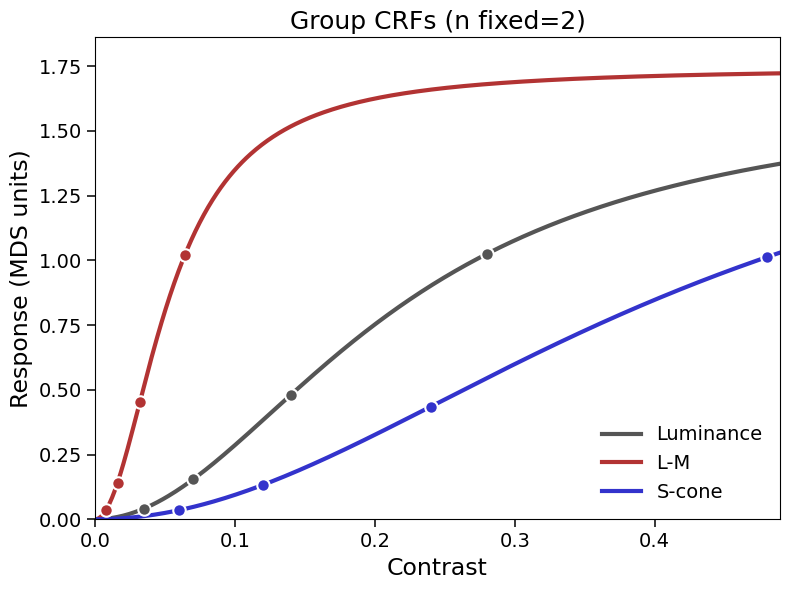

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/Results/all_pathways_CRF_with_4points.png


In [15]:
# ── Cell 4: Group CRFs with visible 4 points on each curve ───────────────────

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Group CRFs (n fixed=2)', fontsize=18)

global_max_contrast = max(info['contrasts'].max() for info in PATHWAYS.values())
x_line = np.linspace(0, global_max_contrast * 1.05, 500)

all_y = []

for pw, info in PATHWAYS.items():
    c = np.array(info['contrasts'], dtype=float)
    color = info['color']
    rows = load_nr(pw)

    Rmaxs, C50s = [], []

    for row in rows:
        if np.isfinite(row['peak_Rmax']) and np.isfinite(row['peak_C50']):
            Rmaxs.append(row['peak_Rmax'])
            C50s.append(row['peak_C50'])

    if len(Rmaxs) == 0:
        continue

    # group mean fit parameters
    Rmax_m = float(np.nanmean(Rmaxs))
    C50_m  = float(np.nanmean(C50s))

    # smooth fitted curve
    y_line = naka_rushton(x_line, Rmax_m, C50_m)
    all_y.append(y_line)
    ax.plot(x_line, y_line, color=color, lw=3, label=pw)

    # 4 visible points at actual contrast values
    y_pts = naka_rushton(c, Rmax_m, C50_m)
    ax.plot(
        c, y_pts,
        'o',
        color=color,
        markersize=9,
        markeredgecolor='white',
        markeredgewidth=1.5,
        zorder=5
    )

ax.set_xlabel('Contrast', fontsize=17)
ax.set_ylabel('Response (MDS units)', fontsize=17)
ax.set_xlim(0, global_max_contrast * 1.02)

if len(all_y) > 0:
    ymax = np.nanmax(np.concatenate(all_y))
    ax.set_ylim(0, ymax * 1.08)

ax.legend(frameon=False, fontsize=14, loc='lower right')
ax.tick_params(axis='both', labelsize=14, width=1.1, length=6)

fig.tight_layout()

out = RES_DIR / 'all_pathways_CRF_with_4points.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

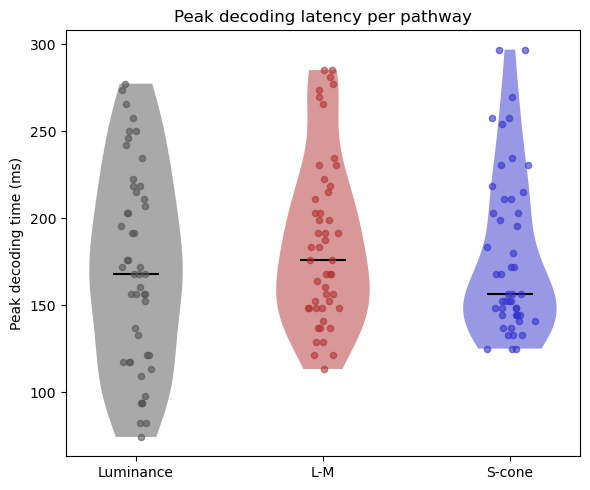

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/Results/peak_latency_per_pathway.png


In [5]:
# ── Cell 5: Peak decoding time per pathway ────────────────────────────────────
# Violin plot showing the distribution of each subject's peak decoding time,
# one violin per pathway. Earlier peak = faster cortical response.

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_title('Peak decoding latency per pathway')

pw_names  = list(PATHWAYS.keys())
pw_colors = [PATHWAYS[pw]['color'] for pw in pw_names]
data      = []

for pw in pw_names:
    _, peak_times, _ = load_peak_accuracy(pw)
    data.append(peak_times * 1000)   # convert to ms

parts = ax.violinplot(data, positions=range(len(pw_names)),
                      showmedians=True, showextrema=False)
for i, (pc, col) in enumerate(zip(parts['bodies'], pw_colors)):
    pc.set_facecolor(col); pc.set_alpha(0.5)
parts['cmedians'].set_color('black')

# Overlay individual points
for i, (d, col) in enumerate(zip(data, pw_colors)):
    ax.scatter(np.random.normal(i, 0.05, len(d)), d,
               color=col, alpha=0.6, s=20, zorder=3)

ax.set_xticks(range(len(pw_names)))
ax.set_xticklabels(pw_names)
ax.set_ylabel('Peak decoding time (ms)')
fig.tight_layout()

out = RES_DIR / 'peak_latency_per_pathway.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

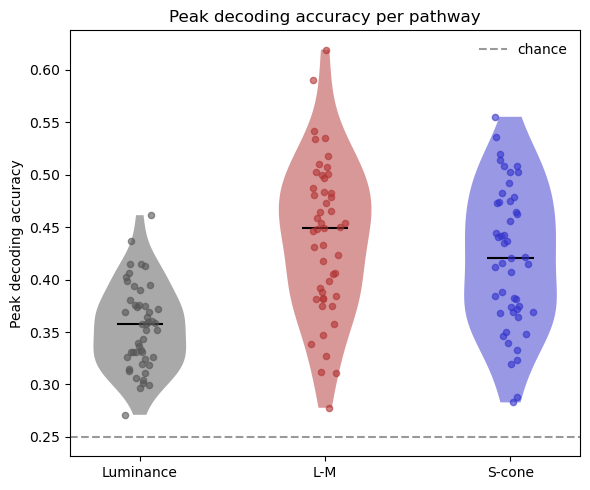

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/Results/peak_accuracy_per_pathway.png


In [6]:
# ── Cell 6: Peak decoding accuracy per pathway ────────────────────────────────
# Same violin layout as Cell 5 but showing accuracy at peak, not timing.

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_title('Peak decoding accuracy per pathway')

data = []
for pw in pw_names:
    _, _, peak_accs = load_peak_accuracy(pw)
    data.append(peak_accs)

parts = ax.violinplot(data, positions=range(len(pw_names)),
                      showmedians=True, showextrema=False)
for i, (pc, col) in enumerate(zip(parts['bodies'], pw_colors)):
    pc.set_facecolor(col); pc.set_alpha(0.5)
parts['cmedians'].set_color('black')

for i, (d, col) in enumerate(zip(data, pw_colors)):
    ax.scatter(np.random.normal(i, 0.05, len(d)), d,
               color=col, alpha=0.6, s=20, zorder=3)

ax.axhline(0.25, ls='--', color='k', alpha=0.4, label='chance')
ax.set_xticks(range(len(pw_names)))
ax.set_xticklabels(pw_names)
ax.set_ylabel('Peak decoding accuracy')
ax.legend(frameon=False)
fig.tight_layout()

out = RES_DIR / 'peak_accuracy_per_pathway.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

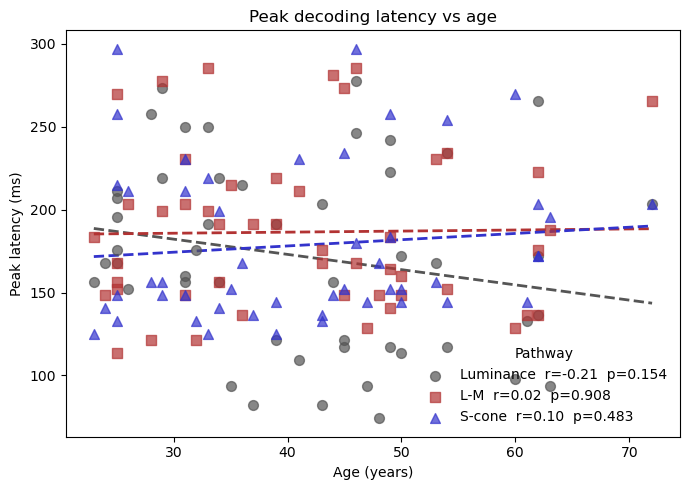

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/Results/latency_vs_age.png


In [21]:
# ── Cell 7: Latency vs age — all three pathways on one plot ──────────────────
MARKERS = {'Luminance': 'o', 'L-M': 's', 'S-cone': '^'}

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Peak decoding latency vs age')

for pw in pw_names:
    color  = PATHWAYS[pw]['color']
    marker = MARKERS[pw]
    _, peak_times, _ = load_peak_accuracy(pw)
    ages_arr = np.array([AGE_DATA[s] for s in SUBJECTS
                         if (ECOC_ROOT / pw / f'sub-{s}_ecoc_results.npz').exists()])
    lat_ms = peak_times * 1000
    mask   = np.isfinite(lat_ms)

    if mask.sum() > 2:
        slope, intercept, r_val, p, xl, yl = regression_line(ages_arr, lat_ms)
        p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
        lbl   = f'{pw}  r={r_val:.2f}  {p_str}'
    else:
        xl, yl = None, None
        lbl = pw

    ax.scatter(ages_arr[mask], lat_ms[mask], color=color, marker=marker,
               alpha=0.7, s=50, zorder=3, label=lbl)
    if xl is not None:
        ax.plot(xl, yl, color=color, lw=2, ls='--')

ax.set_xlabel('Age (years)')
ax.set_ylabel('Peak latency (ms)')
ax.legend(frameon=False, title='Pathway')
fig.tight_layout()
out = RES_DIR / 'latency_vs_age.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

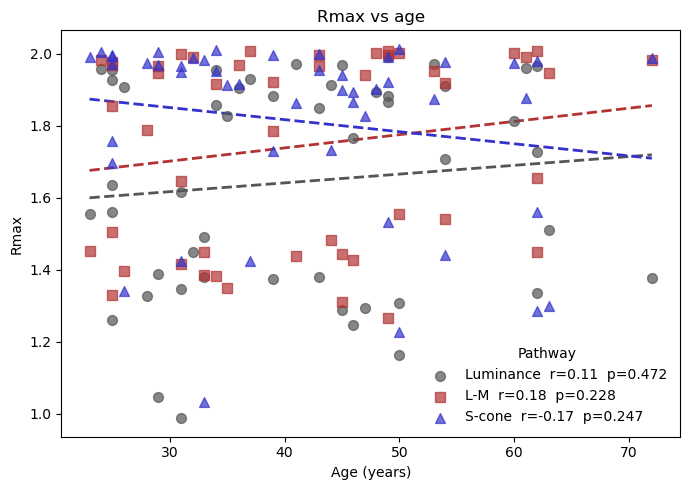

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/Results/Rmax_vs_age.png


In [22]:
# ── Cell 8: Rmax vs age — all three pathways on one plot ─────────────────────
MARKERS = {'Luminance': 'o', 'L-M': 's', 'S-cone': '^'}

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Rmax vs age')

for pw in pw_names:
    color  = PATHWAYS[pw]['color']
    marker = MARKERS[pw]
    rows   = load_nr(pw)
    ages   = np.array([r['age']       for r in rows])
    Rmaxs  = np.array([r['peak_Rmax'] for r in rows])
    mask   = np.isfinite(Rmaxs)

    if mask.sum() > 2:
        slope, intercept, r_val, p, xl, yl = regression_line(ages, Rmaxs)
        p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
        lbl   = f'{pw}  r={r_val:.2f}  {p_str}'
    else:
        xl, yl = None, None
        lbl = pw

    ax.scatter(ages[mask], Rmaxs[mask], color=color, marker=marker,
               alpha=0.7, s=50, zorder=3, label=lbl)
    if xl is not None:
        ax.plot(xl, yl, color=color, lw=2, ls='--')

ax.set_xlabel('Age (years)')
ax.set_ylabel('Rmax')
ax.legend(frameon=False, title='Pathway')
fig.tight_layout()
out = RES_DIR / 'Rmax_vs_age.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

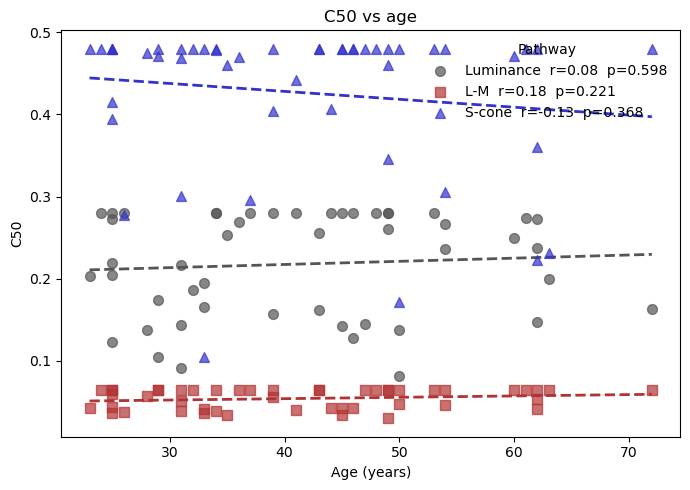

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/Results/C50_vs_age.png


In [23]:
# ── Cell 9: C50 vs age — all three pathways on one plot ──────────────────────
MARKERS = {'Luminance': 'o', 'L-M': 's', 'S-cone': '^'}

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('C50 vs age')

for pw in pw_names:
    color  = PATHWAYS[pw]['color']
    marker = MARKERS[pw]
    rows   = load_nr(pw)
    ages   = np.array([r['age']      for r in rows])
    C50s   = np.array([r['peak_C50'] for r in rows])
    mask   = np.isfinite(C50s)

    if mask.sum() > 2:
        slope, intercept, r_val, p, xl, yl = regression_line(ages, C50s)
        p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
        lbl   = f'{pw}  r={r_val:.2f}  {p_str}'
    else:
        xl, yl = None, None
        lbl = pw

    ax.scatter(ages[mask], C50s[mask], color=color, marker=marker,
               alpha=0.7, s=50, zorder=3, label=lbl)
    if xl is not None:
        ax.plot(xl, yl, color=color, lw=2, ls='--')

ax.set_xlabel('Age (years)')
ax.set_ylabel('C50')
ax.legend(frameon=False, title='Pathway')
fig.tight_layout()
out = RES_DIR / 'C50_vs_age.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

In [10]:
# ── Cell 10: Export all results to CSV ───────────────────────────────────────
# One row per subject per pathway.
# Columns: subject, age, pathway,
#          peak_latency_ms, peak_accuracy, peak_Rmax, peak_C50
# Saved to: Plots/Results/all_results.csv

import csv

rows = []

for pw in pw_names:
    ages_acc, peak_times, peak_accs = load_peak_accuracy(pw)
    nr_lookup   = {r['subject']: r for r in load_nr(pw)}
    pw_subjects = [s for s in SUBJECTS
                   if (ECOC_ROOT / pw / f'sub-{s}_ecoc_results.npz').exists()]

    for i, subject in enumerate(pw_subjects):
        nr = nr_lookup.get(subject, {})
        rows.append({
            'subject':         subject,
            'age':             AGE_DATA[subject],
            'pathway':         pw,
            'peak_latency_ms': round(float(peak_times[i]) * 1000, 2),
            'peak_accuracy':   round(float(peak_accs[i]),          4),
            'peak_Rmax':       round(float(nr.get('peak_Rmax', np.nan)), 4),
            'peak_C50':        round(float(nr.get('peak_C50',  np.nan)), 6),
        })

out_csv    = RES_DIR / 'all_results.csv'
fieldnames = ['subject', 'age', 'pathway',
              'peak_latency_ms', 'peak_accuracy', 'peak_Rmax', 'peak_C50']

with open(out_csv, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f'Saved → {out_csv}')
print(f'Rows  : {len(rows)}  ({len(pw_names)} pathways x ~{len(rows)//len(pw_names)} subjects)')
print()

# Quick preview — first 3 subjects across all pathways
print(f'{"subject":<8} {"age":<5} {"pathway":<10} '
      f'{"lat_ms":<9} {"acc":<7} {"Rmax":<8} {"C50"}')
print('-' * 62)
for r in rows[:9]:
    print(f'{r["subject"]:<8} {r["age"]:<5.0f} {r["pathway"]:<10} '
          f'{r["peak_latency_ms"]:<9.1f} {r["peak_accuracy"]:<7.4f} '
          f'{r["peak_Rmax"]:<8.4f} {r["peak_C50"]:.6f}')

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/Results/all_results.csv
Rows  : 147  (3 pathways x ~49 subjects)

subject  age   pathway    lat_ms    acc     Rmax     C50
--------------------------------------------------------------
1001     25    Luminance  168.0     0.3436  1.9280   0.280000
1002     43    Luminance  203.1     0.3750  1.3787   0.162002
1004     33    Luminance  191.4     0.3244  1.4909   0.194475
1005     50    Luminance  171.9     0.3639  1.3092   0.137082
1007     31    Luminance  160.2     0.4062  0.9880   0.091540
1008     25    Luminance  207.0     0.2711  1.2613   0.122616
1010     26    Luminance  152.3     0.4145  1.9074   0.280000
1011     37    Luminance  82.0      0.3363  1.9302   0.280000
1014     23    Luminance  156.2     0.3515  1.5546   0.203184


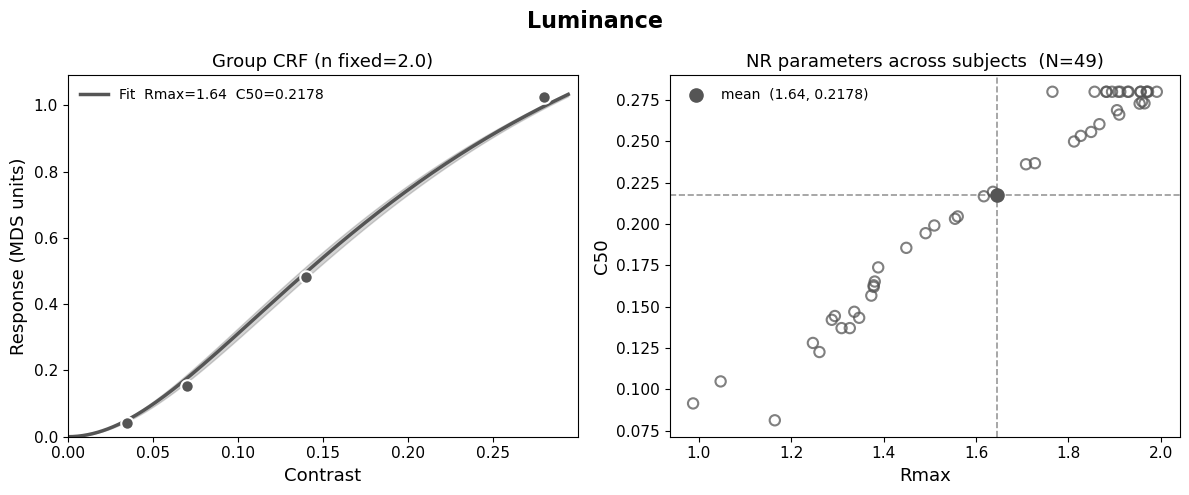

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/Results/Luminance_CRF_and_NR_scatter.png


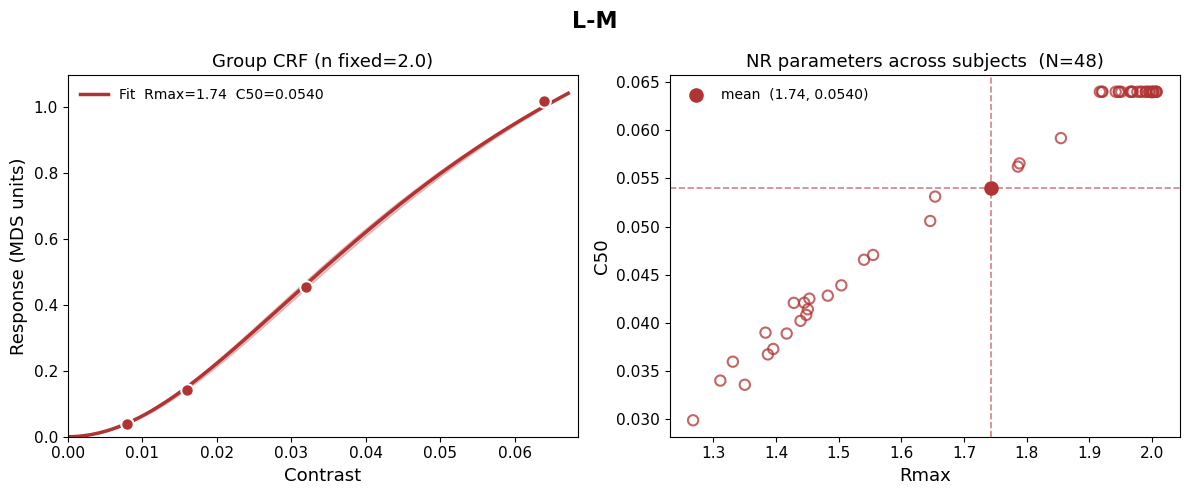

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/Results/L-M_CRF_and_NR_scatter.png


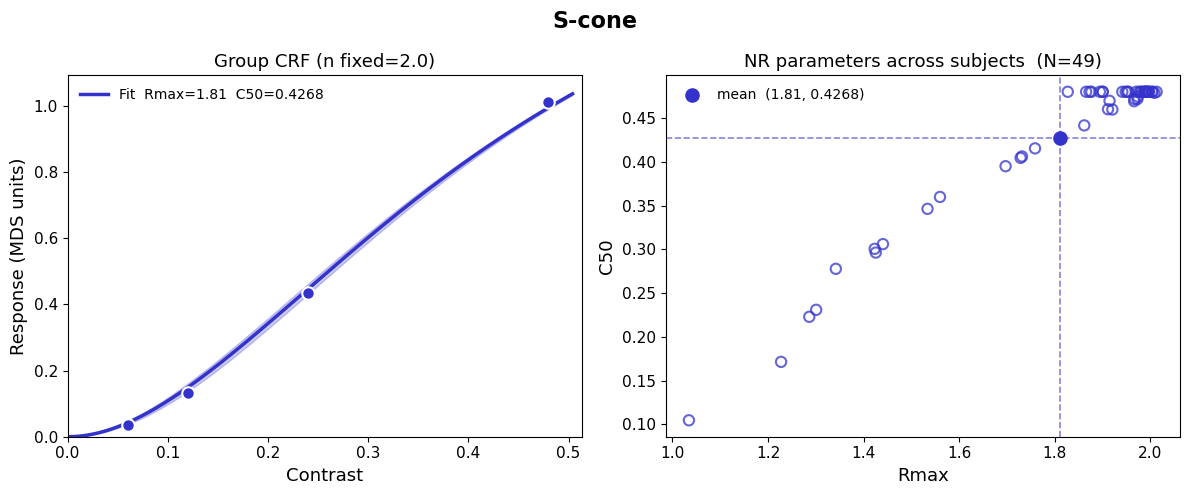

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/Results/S-cone_CRF_and_NR_scatter.png


In [16]:
# ── Cell 11: Per-pathway CRF + Rmax/C50 scatter ──────────────────────────────
# For each pathway produces a two-panel figure:
#   Left  — group mean NR fit with ± SEM shading + 4 data points
#   Right — scatter of individual Rmax vs C50, crosshairs at group mean
# Saved to Plots/Results/<pathway>_CRF_and_NR_scatter.png

for pw, info in PATHWAYS.items():
    c     = np.array(info['contrasts'], float)
    color = info['color']
    rows  = load_nr(pw)

    # Collect valid subjects
    Rmaxs = np.array([r['peak_Rmax'] for r in rows if np.isfinite(r['peak_Rmax'])])
    C50s  = np.array([r['peak_C50']  for r in rows if np.isfinite(r['peak_C50'])])
    if len(Rmaxs) == 0:
        print(f'{pw}: no valid NR fits — skip')
        continue

    Rmax_m = float(np.nanmean(Rmaxs))
    C50_m  = float(np.nanmean(C50s))
    N      = len(Rmaxs)

    # ── Left panel: group CRF with SEM shading ───────────────────────────────
    # Compute SEM band by bootstrapping all individual fits
    x_line  = np.linspace(0, c.max() * 1.05, 300)
    all_curves = np.array([naka_rushton(x_line, r, c50)
                           for r, c50 in zip(Rmaxs, C50s)])
    y_mean  = np.nanmean(all_curves, axis=0)
    y_sem   = np.nanstd(all_curves, axis=0, ddof=1) / np.sqrt(N)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'{pw}', fontsize=16, fontweight='bold')

    ax = axes[0]
    ax.set_title('Group CRF (n fixed=2.0)', fontsize=13)
    ax.fill_between(x_line, y_mean - y_sem, y_mean + y_sem,
                    color=color, alpha=0.25)
    ax.plot(x_line, y_mean, color=color, lw=2.5,
            label=f'Fit  Rmax={Rmax_m:.2f}  C50={C50_m:.4f}')
    # 4 data points at actual contrast values
    y_pts = naka_rushton(c, Rmax_m, C50_m)
    ax.plot(c, y_pts, 'o', color=color, markersize=9,
            markeredgecolor='white', markeredgewidth=1.5, zorder=5)
    ax.set_xlabel('Contrast', fontsize=13)
    ax.set_ylabel('Response (MDS units)', fontsize=13)
    ax.set_xlim(0, c.max() * 1.07)
    ax.set_ylim(0)
    ax.legend(frameon=False, fontsize=10)
    ax.tick_params(labelsize=11)

    # ── Right panel: Rmax vs C50 scatter with crosshairs ─────────────────────
    ax = axes[1]
    ax.set_title(f'NR parameters across subjects  (N={N})', fontsize=13)
    ax.scatter(Rmaxs, C50s, facecolors='none', edgecolors=color,
               s=55, lw=1.5, alpha=0.75, zorder=3)
    # Group mean — filled marker
    ax.scatter(Rmax_m, C50_m, color=color, s=90, zorder=5,
               label=f'mean  ({Rmax_m:.2f}, {C50_m:.4f})')
    # Crosshairs at group mean
    ax.axvline(Rmax_m, color=color, lw=1.2, ls='--', alpha=0.6)
    ax.axhline(C50_m,  color=color, lw=1.2, ls='--', alpha=0.6)
    ax.set_xlabel('Rmax', fontsize=13)
    ax.set_ylabel('C50',  fontsize=13)
    ax.legend(frameon=False, fontsize=10)
    ax.tick_params(labelsize=11)

    fig.tight_layout()
    out = RES_DIR / f'{pw}_CRF_and_NR_scatter.png'
    fig.savefig(out, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out}')